# BA and State Figure 10/11 Analogs

This notebook reproduces the historical balancing-authority and state analogs of Figures 10 and 11 from the packaged scenario metrics. It uses 2007–2023 data, six wind/solar portfolios, and the same stress-event method at both geographic levels.

- **Figure 10:** monthly event starts at the pooled-all-mix 95th-percentile net-load threshold, with minimum event lengths of 1, 6, and 12 hours.
- **Figure 11:** monthly individual threshold-qualifying hours at the same pooled threshold.

A one-hour non-risk gap may bridge two risk-hour runs into one event. Figure 10 event length includes that bridged hour; Figure 11 excludes it because Figure 11 counts individual risk hours.

## Portfolio interpretation

The percentages are shares of combined wind-plus-solar **nameplate capacity**, not shares of annual generation. For total nameplate capacity \(C_{\mathrm{total}}\), wind share \(s_w\), solar share \(s_s\), and hourly capacity factors \(CF_{w,t}\) and \(CF_{s,t}\),

\[
E_t=C_{\mathrm{total}}\left(s_w CF_{w,t}+s_s CF_{s,t}\right)\times 1\ \mathrm{hour}.
\]

Thus, a 75% wind / 25% solar portfolio assigns 75% and 25% of nameplate capacity to wind and solar. Hourly energy follows from the hourly capacity factors; MW multiplied by the one-hour interval gives MWh.

In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

DATA_ROOT = Path("../data")
BUNDLE_ROOT = DATA_ROOT / "wtk_bchrrr_nsrdb_2007_2023"

SCENARIOS = [
    "installed_2024",
    "split_w00_s100",
    "split_w25_s75",
    "split_w50_s50",
    "split_w75_s25",
    "split_w100_s00",
]
LABELS = {
    "installed_2024": "2024 Installed",
    "split_w00_s100": "0% Wind / 100% Solar",
    "split_w25_s75": "25% Wind / 75% Solar",
    "split_w50_s50": "50% Wind / 50% Solar",
    "split_w75_s25": "75% Wind / 25% Solar",
    "split_w100_s00": "100% Wind / 0% Solar",
}
COLORS = {
    "installed_2024": "#111111",
    "split_w00_s100": "#E66101",
    "split_w25_s75": "#E6AB02",
    "split_w50_s50": "#1B9E77",
    "split_w75_s25": "#386CB0",
    "split_w100_s00": "#7B3294",
}
SPECS = {
    "SWPP": (
        "SPP",
        "BA",
        BUNDLE_ROOT / "ba_scenario_metrics"
        / "SWPP_wtk_bchrrr_nsrdb_2007_2023_scenario_metrics.csv",
        "net_load_mw",
    ),
    "MISO_8910": (
        "MISO Local Resource Zone 8–10",
        "BA",
        BUNDLE_ROOT / "ba_scenario_metrics"
        / "MISO_8910_wtk_bchrrr_nsrdb_2007_2023_scenario_metrics.csv",
        "net_load_mw",
    ),
    "IA": (
        "Iowa",
        "state",
        BUNDLE_ROOT / "state_scenario_metrics"
        / "IA_wtk_bchrrr_nsrdb_2007_2023_scenario_metrics.parquet",
        "net_load_mw__raw",
    ),
}
YEARS = list(range(2007, 2024))
P95 = 0.95
MINIMUM_EVENT_HOURS = [1, 6, 12]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for _, _, path, _ in SPECS.values():
    if not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}")

## Shared methods

For each region, the threshold is calculated after pooling hourly net load from all six portfolios. Risk hours meet or exceed that single P95 value. Consecutive risk hours—and runs separated by exactly one non-risk hour—form an event; a larger separation starts a new event.

In [2]:
def load_net_load(path, value_column):
    """Read one packaged product in a common three-column form."""
    columns = ["time_utc", "scenario", value_column]
    if path.suffix == ".parquet":
        hourly = pd.read_parquet(path, columns=columns)
    else:
        hourly = pd.read_csv(path, usecols=columns)

    hourly["time_utc"] = pd.to_datetime(hourly["time_utc"], utc=True)
    hourly = (
        hourly[hourly["scenario"].isin(SCENARIOS)]
        .rename(columns={value_column: "net_load_mw"})
        [["time_utc", "scenario", "net_load_mw"]]
        .sort_values(["scenario", "time_utc"])
        .reset_index(drop=True)
    )

    if hourly.empty or hourly["net_load_mw"].isna().any():
        raise AssertionError("Net-load input is empty or contains missing values.")
    if hourly.duplicated(["scenario", "time_utc"]).any():
        raise AssertionError("Duplicate scenario-hour rows found.")
    if set(hourly["scenario"]) != set(SCENARIOS):
        raise AssertionError("Expected exactly the six documented portfolios.")
    if sorted(hourly["time_utc"].dt.year.unique()) != YEARS:
        raise AssertionError("Expected the complete 2007–2023 period.")
    if hourly.groupby("scenario").size().nunique() != 1:
        raise AssertionError("Portfolio time series have unequal lengths.")
    return hourly


def build_risk_products(hourly, region_code):
    """Apply pooled P95 and the catalog's one-hour bridge rule."""
    threshold = float(hourly["net_load_mw"].quantile(P95))
    risk = (
        hourly[hourly["net_load_mw"].ge(threshold)]
        .sort_values(["scenario", "time_utc"])
        .reset_index(drop=True)
    )
    risk["previous_risk_hour"] = risk.groupby("scenario")["time_utc"].shift()
    risk["elapsed"] = risk["time_utc"] - risk["previous_risk_hour"]
    risk["new_event"] = (
        risk["previous_risk_hour"].isna()
        | risk["elapsed"].gt(pd.Timedelta(hours=2))
    )
    risk["event_id"] = risk.groupby("scenario")["new_event"].cumsum()

    groups = ["scenario", "event_id"]
    events = (
        risk.groupby(groups)
        .agg(
            event_start_utc=("time_utc", "first"),
            event_end_utc=("time_utc", "last"),
            event_risk_hour_count=("time_utc", "size"),
        )
        .reset_index()
    )
    events["event_length_hours"] = (
        (events["event_end_utc"] - events["event_start_utc"])
        / pd.Timedelta(hours=1)
    ).astype(int) + 1

    bridges = risk[risk["elapsed"].eq(pd.Timedelta(hours=2))].copy()
    if bridges.empty:
        events["gap_hours"] = ""
    else:
        bridges["gap_hour"] = (
            bridges["previous_risk_hour"] + pd.Timedelta(hours=1)
        ).dt.strftime("%Y-%m-%dT%H:%M:%SZ")
        gaps = (
            bridges.groupby(groups)["gap_hour"]
            .agg(";".join)
            .reset_index(name="gap_hours")
        )
        events = events.merge(gaps, on=groups, how="left")
        events["gap_hours"] = events["gap_hours"].fillna("")

    events.insert(0, "region_code", region_code)
    events["bridge_gap_hour_count"] = (
        events["event_length_hours"] - events["event_risk_hour_count"]
    )
    return threshold, risk, events


def monthly_event_summary(events):
    """Count event starts and retain every zero-event month."""
    rows = events.copy()
    rows["year"] = rows["event_start_utc"].dt.year
    rows["month"] = rows["event_start_utc"].dt.month
    frames = []
    for minimum in MINIMUM_EVENT_HOURS:
        counts = (
            rows[rows["event_length_hours"].ge(minimum)]
            .groupby(["scenario", "year", "month"])
            .size()
            .reset_index(name="events")
        )
        counts["minimum_event_hours"] = minimum
        frames.append(counts)

    grid = pd.MultiIndex.from_product(
        [SCENARIOS, YEARS, range(1, 13), MINIMUM_EVENT_HOURS],
        names=["scenario", "year", "month", "minimum_event_hours"],
    )
    counts = (
        pd.concat(frames)
        .set_index(["scenario", "year", "month", "minimum_event_hours"])
        .reindex(grid, fill_value=0)
        .reset_index()
    )
    grouped = counts.groupby(
        ["scenario", "month", "minimum_event_hours"]
    )["events"]
    summary = (
        grouped.mean().reset_index(name="mean")
        .merge(
            grouped.quantile(0.10).reset_index(name="p10"),
            on=["scenario", "month", "minimum_event_hours"],
        )
        .merge(
            grouped.quantile(0.90).reset_index(name="p90"),
            on=["scenario", "month", "minimum_event_hours"],
        )
    )
    return counts, summary


def reconstruct_risk_hours(events):
    """Expand event spans and remove every recorded bridge gap."""
    frames = []
    for event in events.itertuples(index=False):
        hours = pd.date_range(
            event.event_start_utc, event.event_end_utc, freq="h"
        )
        gaps = (
            pd.DatetimeIndex([], tz="UTC")
            if event.gap_hours == ""
            else pd.DatetimeIndex(
                pd.to_datetime(event.gap_hours.split(";"), utc=True)
            )
        )
        frames.append(
            pd.DataFrame(
                {
                    "scenario": event.scenario,
                    "time_utc": hours.difference(gaps),
                }
            )
        )
    return pd.concat(frames, ignore_index=True)


def monthly_risk_summary(events, direct_risk):
    """Count individual hours and verify catalog reconstruction."""
    reconstructed = reconstruct_risk_hours(events)
    catalog_keys = reconstructed.sort_values(
        ["scenario", "time_utc"]
    ).reset_index(drop=True)
    direct_keys = (
        direct_risk[["scenario", "time_utc"]]
        .sort_values(["scenario", "time_utc"])
        .reset_index(drop=True)
    )
    pd.testing.assert_frame_equal(catalog_keys, direct_keys)

    reconstructed["year"] = reconstructed["time_utc"].dt.year
    reconstructed["month"] = reconstructed["time_utc"].dt.month
    reconstructed["hours"] = 1
    grid = pd.MultiIndex.from_product(
        [SCENARIOS, YEARS, range(1, 13)],
        names=["scenario", "year", "month"],
    )
    counts = (
        reconstructed.groupby(["scenario", "year", "month"])["hours"]
        .sum()
        .reindex(grid, fill_value=0)
        .reset_index()
    )
    grouped = counts.groupby(["scenario", "month"])["hours"]
    summary = (
        grouped.mean().reset_index(name="mean")
        .merge(
            grouped.quantile(0.10).reset_index(name="p10"),
            on=["scenario", "month"],
        )
        .merge(
            grouped.quantile(0.90).reset_index(name="p90"),
            on=["scenario", "month"],
        )
    )
    return counts, summary


def legend_handles():
    handles = [
        mpatches.Patch(
            facecolor="#BDBDBD",
            edgecolor="none",
            alpha=0.35,
            label="P10–P90 across years",
        ),
        Line2D(
            [0], [0],
            color=COLORS["installed_2024"],
            linewidth=2.2,
            marker="o",
            markersize=4,
            label=LABELS["installed_2024"],
        ),
    ]
    handles.extend(
        Line2D(
            [0], [0],
            color=COLORS[scenario],
            linewidth=2,
            label=LABELS[scenario],
        )
        for scenario in SCENARIOS
        if scenario != "installed_2024"
    )
    return handles


def plot_lines(axis, rows, value_name):
    for scenario in SCENARIOS:
        subset = rows[rows["scenario"].eq(scenario)].sort_values("month")
        x = subset["month"].to_numpy(dtype=int)
        color = COLORS[scenario]
        axis.fill_between(
            x,
            subset["p10"].to_numpy(dtype=float),
            subset["p90"].to_numpy(dtype=float),
            color=color,
            alpha=0.14,
            linewidth=0,
        )
        axis.plot(
            x,
            subset["mean"].to_numpy(dtype=float),
            color=color,
            linewidth=2.2 if scenario == "installed_2024" else 2,
            marker="o" if scenario == "installed_2024" else None,
            markersize=3.5,
        )
    axis.set_ylabel(value_name)
    axis.grid(True, color="#D0D0D0", linewidth=0.8, alpha=0.42)
    axis.set_axisbelow(True)


def plot_event_counts(summary, region_label):
    fig, axes = plt.subplots(
        3, 1, figsize=(10.5, 8.4), sharex=True, dpi=130
    )
    for axis, minimum in zip(axes, MINIMUM_EVENT_HOURS):
        rows = summary[summary["minimum_event_hours"].eq(minimum)]
        plot_lines(axis, rows, "Events")
        axis.text(
            0.015,
            0.88,
            f"≥ {minimum} h event length",
            transform=axis.transAxes,
            bbox={
                "boxstyle": "round,pad=0.18",
                "facecolor": "white",
                "edgecolor": "#BFC4CA",
            },
        )
    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(MONTHS)
    axes[-1].set_xlabel("Month")
    fig.suptitle(f"Figure 10 analog: monthly {region_label} event counts")
    fig.legend(
        handles=legend_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        fontsize=8.5,
    )
    fig.subplots_adjust(
        left=0.09, right=0.985, bottom=0.20, top=0.92, hspace=0.12
    )
    return fig


def plot_risk_hours(summary, region_label):
    fig, axis = plt.subplots(figsize=(10.5, 5.2), dpi=130)
    plot_lines(axis, summary, "Individual risk hours")
    axis.set_xticks(range(1, 13))
    axis.set_xticklabels(MONTHS)
    axis.set_xlabel("Month")
    fig.suptitle(
        f"Figure 11 analog: monthly {region_label} P95 net-load risk hours"
    )
    fig.legend(
        handles=legend_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        fontsize=8.5,
    )
    fig.subplots_adjust(
        left=0.09, right=0.985, bottom=0.30, top=0.88
    )
    return fig

## Load the historical examples

Only the two BAs used by the paper figures and Iowa are loaded. The compact table verifies their common period, six portfolios, pooled P95 thresholds, and event totals.

In [3]:
hourly_by_region = {}
threshold_by_region = {}
risk_by_region = {}
events_by_region = {}
overview_rows = []

for code, (label, level, path, value_column) in SPECS.items():
    hourly = load_net_load(path, value_column)
    threshold, risk, events = build_risk_products(hourly, code)
    hourly_by_region[code] = hourly
    threshold_by_region[code] = threshold
    risk_by_region[code] = risk
    events_by_region[code] = events
    overview_rows.append(
        {
            "level": level,
            "region": label,
            "years": "2007–2023",
            "portfolios": hourly["scenario"].nunique(),
            "pooled_P95_net_load_MW": round(threshold, 2),
            "individual_risk_hours": len(risk),
            "events": len(events),
            "bridge_gap_hours": int(events["bridge_gap_hour_count"].sum()),
        }
    )

overview = pd.DataFrame(overview_rows)
display(overview)

,level,region,years,portfolios,pooled_P95_net_load_MW,individual_risk_hours,events,bridge_gap_hours
0,BA,SPP,2007–2023,6,33677.28,44676,8583,147
1,BA,MISO Local Resource Zone 8–10,2007–2023,6,25714.03,44676,7441,522
2,state,Iowa,2007–2023,6,6358.08,44676,9141,305


### Iowa catalog cross-check

The generated Iowa event spans are checked against the packaged historical state catalog. This confirms exact agreement for event starts, ends, lengths, and recorded bridge gaps.

In [4]:
catalog_path = (
    BUNDLE_ROOT / "state_stress_event_catalog"
    / "IA_wtk_bchrrr_nsrdb_2007_2023_events.csv"
)
packaged = pd.read_csv(catalog_path, keep_default_na=False)
packaged = packaged[
    packaged["metric"].str.startswith("net_load_mw__raw__")
    & packaged["threshold_quantile"].eq(P95)
].copy()
packaged["scenario"] = packaged["metric"].str.removeprefix(
    "net_load_mw__raw__"
)
for column in ["event_start_utc", "event_end_utc"]:
    packaged[column] = pd.to_datetime(packaged[column], utc=True)

columns = [
    "scenario",
    "event_start_utc",
    "event_end_utc",
    "event_length_hours",
    "gap_hours",
]
generated = (
    events_by_region["IA"][columns]
    .sort_values(["scenario", "event_start_utc"])
    .reset_index(drop=True)
)
packaged = (
    packaged[columns]
    .sort_values(["scenario", "event_start_utc"])
    .reset_index(drop=True)
)
pd.testing.assert_frame_equal(generated, packaged, check_dtype=False)

display(
    pd.DataFrame(
        [{
            "check": "Generated Iowa P95 events match packaged catalog",
            "events_compared": len(generated),
            "result": "PASS",
        }]
    )
)

,check,events_compared,result
0,Generated Iowa P95 events match packaged catalog,9141,PASS


## Balancing-authority analogs

Figure 10 uses SPP (SWPP). Figure 11 uses MISO Local Resource Zone 8–10 (MISO_8910). Both use a region-specific threshold calculated by pooling all six portfolios.

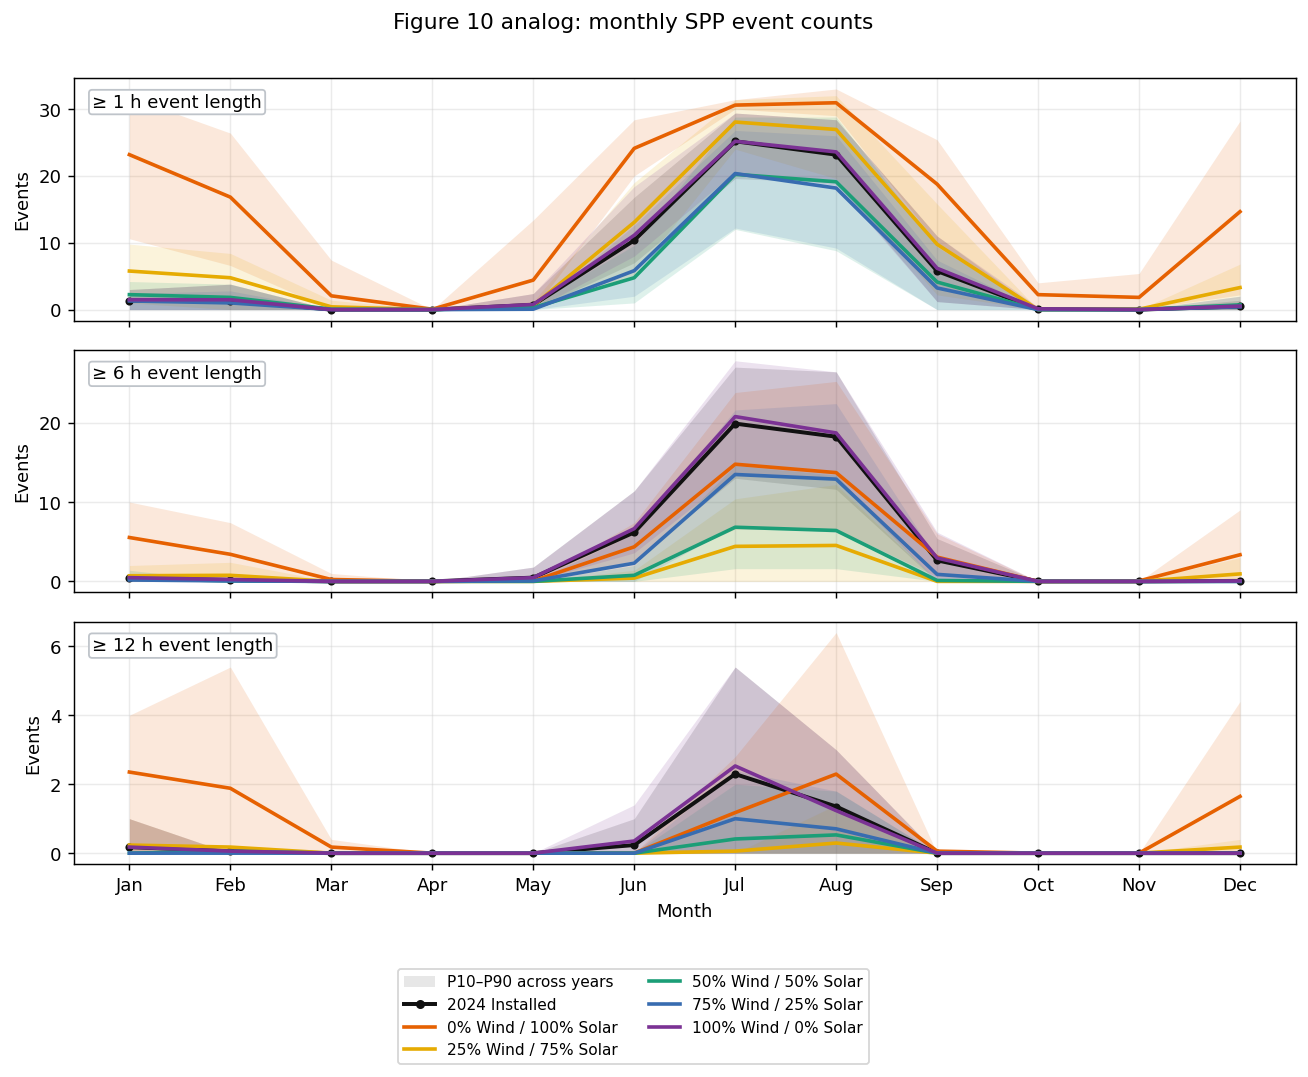

In [5]:
swpp_monthly_events, swpp_event_summary = monthly_event_summary(
    events_by_region["SWPP"]
)
figure_10_ba = plot_event_counts(
    swpp_event_summary, SPECS["SWPP"][0]
)
display(figure_10_ba)
plt.close(figure_10_ba)

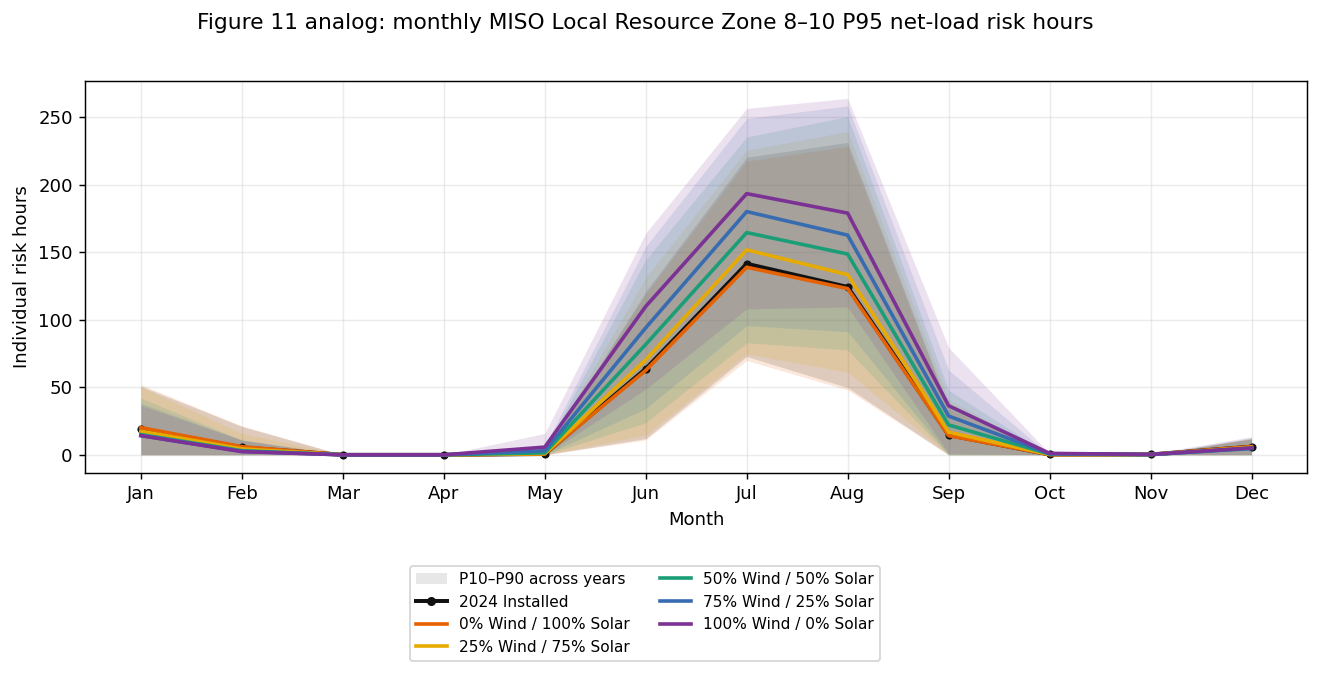

In [6]:
miso_monthly_risk, miso_risk_summary = monthly_risk_summary(
    events_by_region["MISO_8910"],
    risk_by_region["MISO_8910"],
)
figure_11_ba = plot_risk_hours(
    miso_risk_summary, SPECS["MISO_8910"][0]
)
display(figure_11_ba)
plt.close(figure_11_ba)

## State analogs

Iowa is processed with the same functions, threshold convention, bridge rule, complete month grids, and plotting definitions. Figure 11 counts only the original threshold-qualifying hours; bridge gaps are removed during catalog expansion.

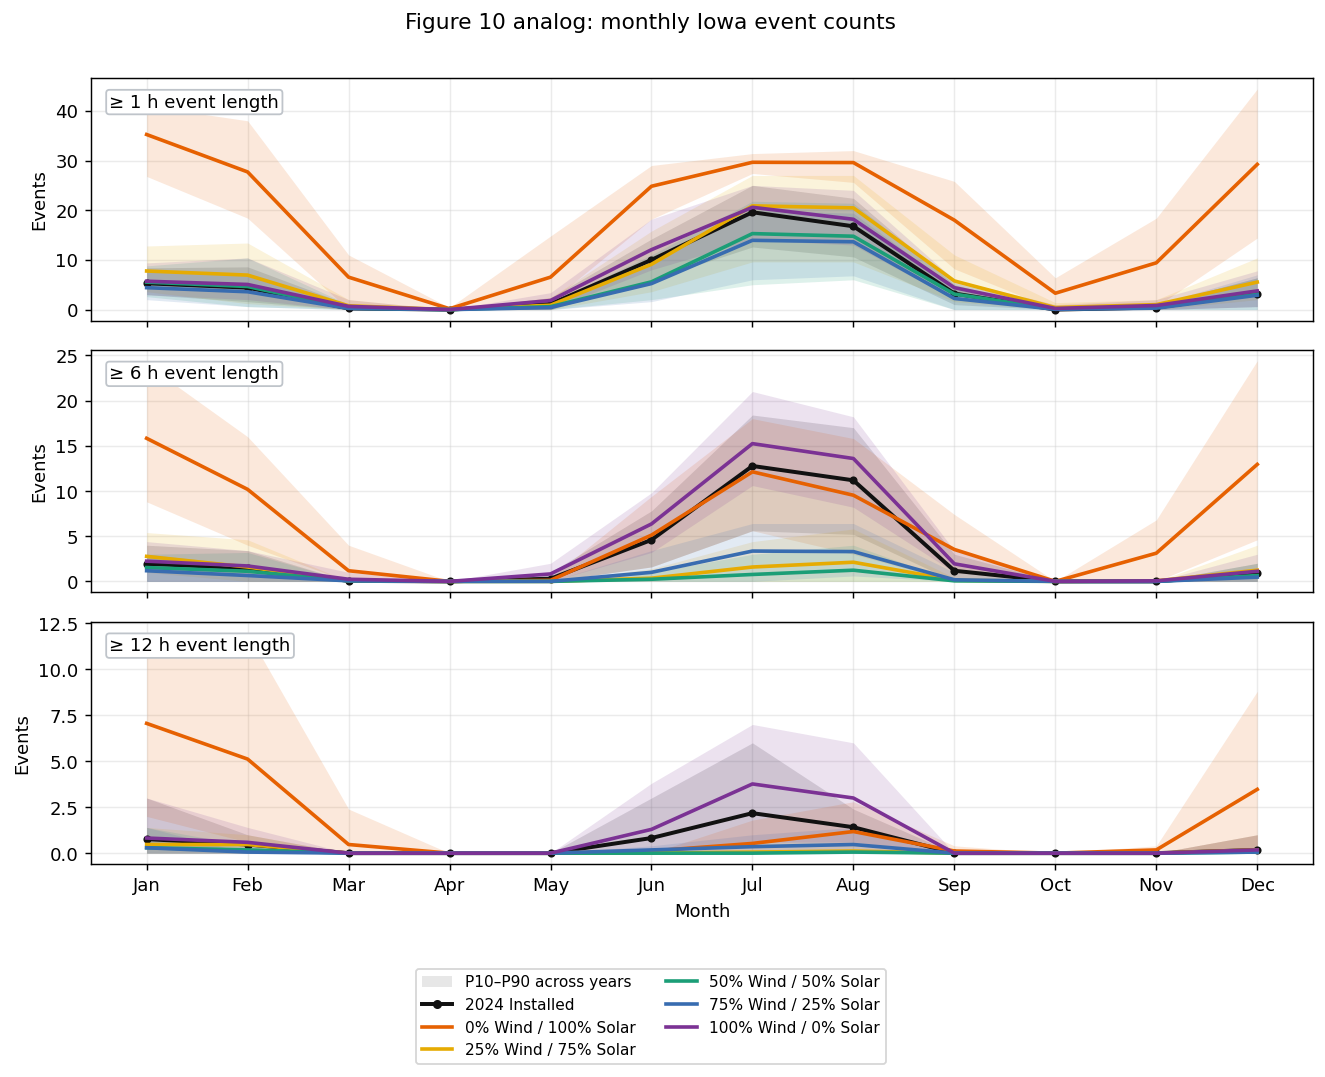

In [7]:
iowa_monthly_events, iowa_event_summary = monthly_event_summary(
    events_by_region["IA"]
)
figure_10_state = plot_event_counts(
    iowa_event_summary, SPECS["IA"][0]
)
display(figure_10_state)
plt.close(figure_10_state)

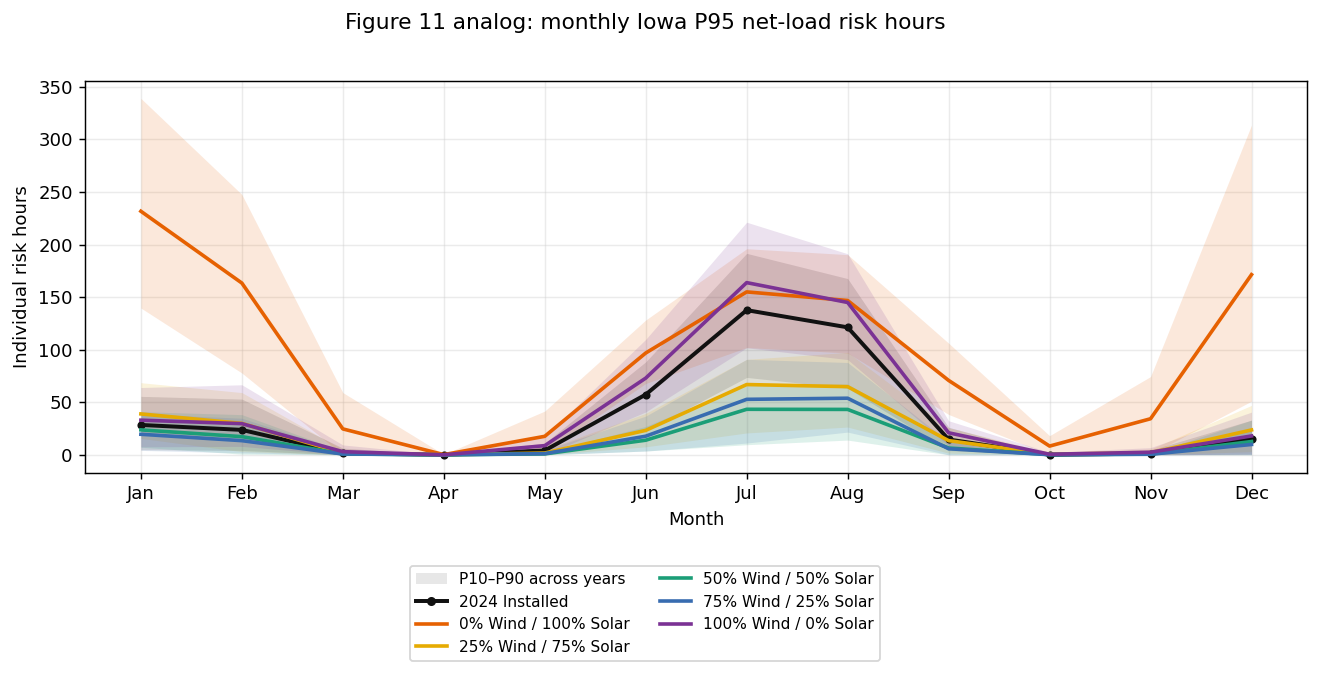

In [8]:
iowa_monthly_risk, iowa_risk_summary = monthly_risk_summary(
    events_by_region["IA"],
    risk_by_region["IA"],
)
figure_11_state = plot_risk_hours(
    iowa_risk_summary, SPECS["IA"][0]
)
display(figure_11_state)
plt.close(figure_11_state)

## Verification

The grids include all six portfolios, all 17 years, and all 12 months. Zero-event and zero-risk months remain explicit. Catalog-expanded Figure 11 hours must equal the direct risk-hour tables after bridge gaps are removed.

In [9]:
expected_figure_10_rows = len(SCENARIOS) * len(YEARS) * 12 * 3
expected_figure_11_rows = len(SCENARIOS) * len(YEARS) * 12

assert len(swpp_monthly_events) == expected_figure_10_rows
assert len(iowa_monthly_events) == expected_figure_10_rows
assert len(miso_monthly_risk) == expected_figure_11_rows
assert len(iowa_monthly_risk) == expected_figure_11_rows
assert int(
    swpp_monthly_events.loc[
        swpp_monthly_events["minimum_event_hours"].eq(1), "events"
    ].sum()
) == len(events_by_region["SWPP"])
assert int(
    iowa_monthly_events.loc[
        iowa_monthly_events["minimum_event_hours"].eq(1), "events"
    ].sum()
) == len(events_by_region["IA"])
assert int(miso_monthly_risk["hours"].sum()) == len(
    risk_by_region["MISO_8910"]
)
assert int(iowa_monthly_risk["hours"].sum()) == len(
    risk_by_region["IA"]
)
assert all(
    events["event_length_hours"].ge(
        events["event_risk_hour_count"]
    ).all()
    for events in events_by_region.values()
)

verification = pd.DataFrame(
    [
        {
            "figure": "10 BA",
            "region": "SPP",
            "grid_rows": len(swpp_monthly_events),
            "explicit_zero_rows": int(
                swpp_monthly_events["events"].eq(0).sum()
            ),
            "excluded_bridge_hours": "not applicable",
            "result": "PASS",
        },
        {
            "figure": "10 state",
            "region": "Iowa",
            "grid_rows": len(iowa_monthly_events),
            "explicit_zero_rows": int(
                iowa_monthly_events["events"].eq(0).sum()
            ),
            "excluded_bridge_hours": "not applicable",
            "result": "PASS",
        },
        {
            "figure": "11 BA",
            "region": "MISO LRZ 8–10",
            "grid_rows": len(miso_monthly_risk),
            "explicit_zero_rows": int(
                miso_monthly_risk["hours"].eq(0).sum()
            ),
            "excluded_bridge_hours": int(
                events_by_region["MISO_8910"][
                    "bridge_gap_hour_count"
                ].sum()
            ),
            "result": "PASS",
        },
        {
            "figure": "11 state",
            "region": "Iowa",
            "grid_rows": len(iowa_monthly_risk),
            "explicit_zero_rows": int(
                iowa_monthly_risk["hours"].eq(0).sum()
            ),
            "excluded_bridge_hours": int(
                events_by_region["IA"][
                    "bridge_gap_hour_count"
                ].sum()
            ),
            "result": "PASS",
        },
    ]
)

print("All Figure 10/11 checks passed.")
display(verification)

All Figure 10/11 checks passed.


,figure,region,grid_rows,explicit_zero_rows,excluded_bridge_hours,result
0,10 BA,SPP,3672,2448,not applicable,PASS
1,10 state,Iowa,3672,2084,not applicable,PASS
2,11 BA,MISO LRZ 8–10,1224,655,522,PASS
3,11 state,Iowa,1224,361,305,PASS
